<a href="https://colab.research.google.com/github/ardominguezm/golden-age-semantic-reconfiguration/blob/main/notebooks/paper1_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paper 1 — Golden Age Semantic Reconfiguration

**Current stage: Phase 12 — Lexical Turnover vs Persistent-Concept Rewiring**

## Scientific target
The paper asks whether the Renaissance→Baroque transition is merely gradual semantic drift or whether the poetic semantic system undergoes **structural reorganization**. Phase 12 is the first phase that measures temporal semantic change, but it keeps historiography outside the estimator.

The main representation was selected blindly in Phase 11B: **within-line concept co-occurrence, support ≥1, PPMI**. Phase 12 decomposes adjacent-window change into (i) **lexical turnover** in the active concept set and (ii) **relational rewiring among concepts that persist in both windows**.

No 1580/1605 comparison, historiographic label, change-point model, or historical claim is made here. The output is an uncertainty-aware semantic reconfiguration trajectory that will later be tested against null/counterfactual baselines before historiographic validation.


In [1]:
import sys, subprocess, hashlib, urllib.request, re, shutil, unicodedata, math
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
from functools import lru_cache
from difflib import SequenceMatcher
import numpy as np, pandas as pd
import xml.etree.ElementTree as ET

SPACY_VERSION='3.8.7'; MODEL_NAME='es_core_news_sm'; MODEL_VERSION='3.8.0'
MODEL_URL='https://github.com/explosion/spacy-models/releases/download/es_core_news_sm-3.8.0/es_core_news_sm-3.8.0-py3-none-any.whl'
MODEL_SHA256='e451a83d6df79b87e9eed0cb553f03e99e36a3bab18a7b79f0dcfd1fdf875e12'
wheel=Path('/content/es_core_news_sm-3.8.0-py3-none-any.whl')
if not wheel.exists() or hashlib.sha256(wheel.read_bytes()).hexdigest()!=MODEL_SHA256:
    urllib.request.urlretrieve(MODEL_URL,wheel)
assert hashlib.sha256(wheel.read_bytes()).hexdigest()==MODEL_SHA256
subprocess.run([sys.executable,'-m','pip','install','-q',f'spacy=={SPACY_VERSION}',str(wheel)],check=True)
import spacy
assert spacy.__version__==SPACY_VERSION,spacy.__version__
nlp=spacy.load(MODEL_NAME,disable=['parser','ner'])
assert nlp.meta.get('version')==MODEL_VERSION,nlp.meta
print('Environment ready:',f'spaCy {spacy.__version__}',f'| {MODEL_NAME} {nlp.meta.get("version")}')


Environment ready: spaCy 3.8.7 | es_core_news_sm 3.8.0


In [2]:
# Reproduce the frozen 97-poem chronology exactly as in Phases 10–11B.
SOURCES={
 'navarro_tei':('https://github.com/bncolorado/CorpusSonetosSigloDeOro.git','092a5fe70a4065a4d84bfed288bffd3851348f9c'),
 'gongora_scholarly':('https://github.com/gongoradigital/gongoraobra.git','3beadeecc059a7cc48499dc2683bb378a2630978'),
}
ROOT=Path('/content/gasr_phase12_sources'); ROOT.mkdir(exist_ok=True)
def clone(name,url,commit):
    dst=ROOT/name
    if dst.exists(): shutil.rmtree(dst)
    subprocess.run(['git','clone','--quiet',url,str(dst)],check=True)
    subprocess.run(['git','-C',str(dst),'checkout','--quiet',commit],check=True)
    got=subprocess.check_output(['git','-C',str(dst),'rev-parse','HEAD'],text=True).strip()
    assert got==commit,(name,got,commit)
    return dst
paths={k:clone(k,*v) for k,v in SOURCES.items()}
N=paths['navarro_tei']; G=paths['gongora_scholarly']; XML_ID='{http://www.w3.org/XML/1998/namespace}id'
def local(tag): return tag.split('}')[-1] if '}' in tag else tag
def el_text(el): return '' if el is None else ' '.join(' '.join(el.itertext()).split())
def norm(s):
    s=unicodedata.normalize('NFKD',str(s)); s=''.join(c for c in s if not unicodedata.combining(c))
    return re.sub(r'[^a-z0-9]','',s.lower())
def years_1580_1626(s):
    return sorted(set(int(x) for x in re.findall(r'(?<!\d)(1[56]\d{2})(?!\d)',str(s)) if 1580<=int(x)<=1626))

rows=[]
for fp in sorted(N.rglob('*.xml')):
    root=ET.parse(fp).getroot(); lines=[el_text(x) for x in root.iter() if local(x.tag)=='l']; lines=[x for x in lines if x]
    if not lines: continue
    author=fp.parent.name; txt='\n'.join(lines)
    rows.append({'n_id':f'{author}::{fp.name}','author_dir':author,'source_file':str(fp.relative_to(N)),
                 'n_lines':len(lines),'lines':lines,'text_tei':txt,'signature':norm(txt),
                 'first2_signature':norm('\n'.join(lines[:2])),'first_line':lines[0]})
n=pd.DataFrame(rows); assert len(n)==5078,len(n)

primary_rows=[]
def add(pid,author,lo,hi,confidence,basis):
    primary_rows.append({'n_id':pid,'author_dir':author,'composition_min':int(lo),'composition_max':int(hi),
                         'temporal_confidence':confidence,'temporal_basis':basis})

# Góngora scholarly-year links frozen from Phases 4/5.
groot=ET.parse(G/'gongora_obra-poetica.xml').getroot(); parent={child:par for par in groot.iter() for child in par}; grows=[]
for el in groot.iter():
    xid=el.attrib.get(XML_ID,'')
    if local(el.tag)!='div' or not xid.lower().startswith('poem'): continue
    lines=[el_text(x) for x in el.iter() if local(x.tag)=='l']; lines=[x for x in lines if x]
    if not lines: continue
    vals=[]; cur=el
    for _ in range(6):
        vals+=list(cur.attrib.values())
        if cur.text: vals.append(cur.text)
        for ch in list(cur):
            if local(ch.tag) in {'head','date','label'}: vals.append(el_text(ch))
            if ch.tail: vals.append(ch.tail)
        cur=parent.get(cur)
        if cur is None: break
    ys=sorted(set(y for v in vals for y in years_1580_1626(v))); txt='\n'.join(lines)
    grows.append({'g_id':xid,'n_lines':len(lines),'signature':norm(txt),'first2_signature':norm('\n'.join(lines[:2])),
                  'scholarly_year':ys[0] if len(ys)==1 else pd.NA,
                  'year_status':'unique' if len(ys)==1 else ('ambiguous' if len(ys)>1 else 'missing')})
g=pd.DataFrame(grows); g14=g[(g.n_lines==14)&g.signature.ne('')].copy(); g_by_id=g.set_index('g_id',drop=False)
ng=n[n.author_dir.eq('Gongora')].copy(); sig_to_gids=g14.groupby('signature').g_id.apply(list).to_dict(); links=[]
for r in ng.itertuples(index=False):
    exact_ids=sig_to_gids.get(r.signature,[])
    if len(exact_ids)==1: gid,score,method=exact_ids[0],1.0,'exact'
    else:
        best_gid,best_score=None,-1.0
        for gr in g14.itertuples(index=False):
            sc=SequenceMatcher(None,r.signature,gr.signature).ratio()
            if sc>best_score: best_gid,best_score=gr.g_id,sc
        gid,score,method=best_gid,best_score,'fuzzy'
    links.append({'n_id':r.n_id,'g_id':gid,'method':method,'score':float(score),'preaccept':method=='exact' or score>=0.98})
glink=pd.DataFrame(links); pre=glink[glink.preaccept].copy(); collisions=set(pre.g_id.value_counts()[lambda s:s>1].index)
glink['accept_phase4']=glink.preaccept&~glink.g_id.isin(collisions)
acc=glink[glink.accept_phase4].merge(g[['g_id','scholarly_year','year_status']],on='g_id',how='left')
acc=acc[acc.year_status.eq('unique')&acc.scholarly_year.notna()].copy()
for r in acc.itertuples(index=False):
    add(r.n_id,'Gongora',r.scholarly_year,r.scholarly_year,'A' if r.method=='exact' else 'B',
        'scholarly_chronology_year_exact_link' if r.method=='exact' else 'scholarly_chronology_year_fuzzy_link')
phase4_nids=set(acc.n_id); phase4_gids=set(acc.g_id); unmatched=ng[~ng.n_id.isin(phase4_nids)].copy()
first2_index=g14.groupby('first2_signature').g_id.apply(list).to_dict(); recovered=[]
for r in unmatched.itertuples(index=False):
    ids2=first2_index.get(r.first2_signature,[])
    if len(ids2)!=1: continue
    gid=ids2[0]
    if gid in phase4_gids: continue
    gr=g_by_id.loc[gid]; score=SequenceMatcher(None,r.signature,gr.signature).ratio()
    if score>=0.95 and gr.year_status=='unique' and pd.notna(gr.scholarly_year):
        recovered.append((r.n_id,gid,score,int(gr.scholarly_year)))
rec=pd.DataFrame(recovered,columns=['n_id','g_id','score','year']); dup=set(rec.g_id.value_counts()[lambda s:s>1].index) if len(rec) else set(); rec=rec[~rec.g_id.isin(dup)]
for r in rec.itertuples(index=False): add(r.n_id,'Gongora',r.year,r.year,'B','scholarly_chronology_year_variant_link')
assert sum(x['author_dir']=='Gongora' for x in primary_rows)==58

GAR={**{i:(1526,1532,'B','scholarly_phase_interval') for i in [1,2,3,4,6,26,27]},
     25:(1534,1535,'B','scholarly_interval'),33:(1535,1535,'A','historically_anchored_scholarly_year'),
     35:(1535,1535,'A','historically_anchored_scholarly_year'),
     **{i:(1533,1535,'B','revised_scholarly_interval') for i in [7,8,12,15,19,28,30,31]}}
for no,(lo,hi,conf,basis) in GAR.items(): add(f'GarcilasoDeLaVega::GarcilasoDeLaVega_{no:02d}.xml','GarcilasoDeLaVega',lo,hi,conf,basis)
for no,lo,hi,conf,basis in [(30,1596,1596,'B','Cadiz_1596'),(13,1598,1598,'A','FelipeII_tomb_1598'),(31,1597,1598,'B','Herrera_death_epitaph')]:
    add(f'Cervantes::Cervantes_{no}.xml','Cervantes',lo,hi,conf,basis)
for no,lo,hi,basis in [(224,1574,1574,'Alameda_CarlosV'),(279,1578,1579,'Barahona_Granada'),(276,1573,1574,'Bazan_Tunis'),
                       (300,1580,1582,'Portugal_to_H'),(281,1578,1578,'DonJuan_de_Austria')]:
    add(f'FernandoDeHerrera::FernandoDeHerrera_{no}.xml','FernandoDeHerrera',lo,hi,'B',basis)
for no in [2,19,4,5]: add(f'PedroEspinosa::PedroEspinosa_{no}.xml','PedroEspinosa',1594,1596,'B','Espinosa_happiness_period_1594_1596')
for no,year,basis in [(131,1609,'Carrillo_sonnet_1609'),(69,1611,'Aminta_1611'),(70,1611,'Aminta_1611'),(72,1611,'Aminta_1611'),
                      (76,1611,'Aminta_1611'),(42,1610,'HenryIV_1610'),(43,1610,'HenryIV_1610'),(45,1610,'HenryIV_1610'),(44,1624,'Osuna_1624')]:
    add(f'Quevedo::Quevedo_{no}.xml','Quevedo',year,year,'B',basis)

primary=pd.DataFrame(primary_rows).drop_duplicates('n_id').copy()
expected={'Gongora':58,'GarcilasoDeLaVega':18,'Quevedo':9,'FernandoDeHerrera':5,'PedroEspinosa':4,'Cervantes':3}
assert len(primary)==97 and primary.groupby('author_dir').size().to_dict()==expected
primary=primary.merge(n[['n_id','text_tei','lines','n_lines','source_file','first_line','signature']],on='n_id',how='left',validate='one_to_one')
assert primary.text_tei.notna().all()
print('FROZEN PRIMARY CHRONOLOGY REPRODUCED:',len(primary),'poems |',primary.author_dir.nunique(),'authors')


FROZEN PRIMARY CHRONOLOGY REPRODUCED: 97 poems | 6 authors


In [3]:
# Reproduce the Phase-10 vocabulary and the Phase-11B selected line context.
MAIN_POS={'NOUN','VERB','ADJ','ADV'}; MIN_LEMMA_LEN=2
line_records=[]
for r in primary.itertuples(index=False):
    for line_no,line in enumerate(r.lines,1): line_records.append((r.n_id,r.author_dir,line_no,line))
docs=list(nlp.pipe([x[3] for x in line_records],batch_size=128)); assert len(docs)==len(line_records)
token_rows=[]
for (pid,author,line_no,_),doc in zip(line_records,docs):
    for t in doc:
        lemma=unicodedata.normalize('NFC',str(t.lemma_)).strip().lower(); pos=t.pos_
        keep=bool(t.is_alpha and pos in MAIN_POS and len(lemma)>=MIN_LEMMA_LEN)
        token_rows.append({'n_id':pid,'author_dir':author,'line_no':line_no,'surface':t.text,'lemma':lemma,'pos':pos,
                           'is_main_content':keep,'concept':f'{lemma}::{pos}' if keep else pd.NA})
tokens=pd.DataFrame(token_rows); main_tok=tokens[tokens.is_main_content].copy()
concept_df=(main_tok[['n_id','concept','lemma','pos']].drop_duplicates(['n_id','concept'])
            .groupby(['concept','lemma','pos']).n_id.nunique().rename('poem_df').reset_index())
concept_tf=main_tok.groupby('concept').size().rename('token_frequency').reset_index(); vocab=concept_df.merge(concept_tf,on='concept',how='left')
MAIN_VOCAB=set(vocab.loc[vocab.poem_df.ge(2),'concept']); assert len(MAIN_VOCAB)==668,len(MAIN_VOCAB)
assert len(tokens)==10439 and int(tokens.is_main_content.sum())==4358,(len(tokens),int(tokens.is_main_content.sum()))
poem_line_units={r.n_id:[set() for _ in range(r.n_lines)] for r in primary.itertuples(index=False)}
for (pid,line_no),grp in main_tok[main_tok.concept.isin(MAIN_VOCAB)].groupby(['n_id','line_no']):
    poem_line_units[pid][int(line_no)-1]=set(grp.concept)
assert set(poem_line_units)==set(primary.n_id)
print('Phase-10/11B representation reproduced:',len(MAIN_VOCAB),'concepts | line context | support >=1')


Phase-10/11B representation reproduced: 668 concepts | line context | support >=1


In [4]:
# Freeze Phase-12 metrics before computing the trajectory.
SELECTED_REPRESENTATION='B_line_support1'; MIN_PAIR_SUPPORT=1
SEED=20260825; MC_DRAWS=1000
MAIN_WINDOWS=[(s,s+19) for s in range(1565,1606,5)]; assert len(MAIN_WINDOWS)==9
TRANSITIONS=[(MAIN_WINDOWS[i],MAIN_WINDOWS[i+1]) for i in range(len(MAIN_WINDOWS)-1)]; assert len(TRANSITIONS)==8
metric_spec=pd.DataFrame([
 ('lexical_turnover','1 - node-set Jaccard','primary lexical'),
 ('rewiring_cosine','1 - cosine(PPMI vectors on persistent concepts)','primary relational'),
 ('rewiring_edge_jaccard','1 - edge-set Jaccard on persistent concepts','secondary relational'),
 ('rewiring_jsd','base-2 Jensen-Shannon divergence of normalized persistent-edge PPMI','secondary relational'),
 ('poem_turnover','1 - poem-set Jaccard','sampling diagnostic'),
 ('author_share_tv','total-variation distance of raw author shares','sampling diagnostic'),
 ('raw_balanced_abs_diff','absolute raw-vs-balanced rewiring-cosine difference','author-dominance diagnostic'),
],columns=['quantity','definition','role'])
print('PHASE 12 METRICS FROZEN BEFORE TRAJECTORY')
display(metric_spec)
print('Historiographic markers used in metric definition: FALSE')
print('Change-point model specified: FALSE')


PHASE 12 METRICS FROZEN BEFORE TRAJECTORY


,quantity,definition,role
0,lexical_turnover,1 - node-set Jaccard,primary lexical
1,rewiring_cosine,1 - cosine(PPMI vectors on persistent concepts),primary relational
2,rewiring_edge_jaccard,1 - edge-set Jaccard on persistent concepts,secondary relational
3,rewiring_jsd,base-2 Jensen-Shannon divergence of normalized...,secondary relational
4,poem_turnover,1 - poem-set Jaccard,sampling diagnostic
5,author_share_tv,total-variation distance of raw author shares,sampling diagnostic
6,raw_balanced_abs_diff,absolute raw-vs-balanced rewiring-cosine diffe...,author-dominance diagnostic


Historiographic markers used in metric definition: FALSE
Change-point model specified: FALSE


In [5]:
primary_idx=primary.set_index('n_id',drop=False)

@lru_cache(maxsize=None)
def build_state(ids_tuple,mode):
    ids=list(ids_tuple)
    if not ids: raise ValueError('Empty temporal window')
    sub=primary_idx.loc[ids]; author_counts=Counter(sub.author_dir)
    node_mass=defaultdict(float); pair_mass=defaultdict(float); total_mass=0.0
    for pid in ids:
        units=poem_line_units[pid]; U=len(units); author=primary_idx.loc[pid].author_dir
        unit_weight=1.0 if mode=='raw' else 1.0/(author_counts[author]*U)
        total_mass+=U*unit_weight
        for concepts in units:
            concepts=sorted(concepts)
            for u in concepts: node_mass[u]+=unit_weight
            for u,v in combinations(concepts,2): pair_mass[(u,v)]+=unit_weight
    active=frozenset(u for u,c in node_mass.items() if c>0); edges={}
    for (u,v),mass in pair_mass.items():
        # Phase 11B selected support>=1, so every observed pair is eligible.
        pij=mass/total_mass; pi=node_mass[u]/total_mass; pj=node_mass[v]/total_mass
        if min(pij,pi,pj)<=0: continue
        ppmi=max(0.0,math.log2(pij/(pi*pj)))
        if ppmi>0: edges[(u,v)]=float(ppmi)
    return {'nodes':active,'edges':edges,'n_nodes':len(active),'n_edges':len(edges)}

def jaccard_distance(A,B):
    U=A|B
    return np.nan if not U else 1.0-len(A&B)/len(U)

def cosine_distance_sparse(a,b,keys):
    if not keys: return np.nan
    x=np.fromiter((a.get(k,0.0) for k in keys),dtype=float); y=np.fromiter((b.get(k,0.0) for k in keys),dtype=float)
    nxv=float(np.linalg.norm(x)); nyv=float(np.linalg.norm(y))
    if nxv==0 or nyv==0: return np.nan
    return float(1.0-np.dot(x,y)/(nxv*nyv))

def js_divergence_sparse(a,b,keys):
    if not keys: return np.nan
    x=np.fromiter((a.get(k,0.0) for k in keys),dtype=float); y=np.fromiter((b.get(k,0.0) for k in keys),dtype=float)
    if x.sum()<=0 or y.sum()<=0: return np.nan
    p=x/x.sum(); q=y/y.sum(); m=.5*(p+q)
    def kl(r,s):
        mask=r>0
        return float(np.sum(r[mask]*np.log2(r[mask]/s[mask])))
    return float(.5*kl(p,m)+.5*kl(q,m))

def author_composition(ids_tuple):
    c=Counter(primary_idx.loc[list(ids_tuple)].author_dir); n=sum(c.values())
    return {a:v/n for a,v in c.items()} if n else {}

def author_tv(a,b):
    keys=set(a)|set(b)
    return .5*sum(abs(a.get(k,0.0)-b.get(k,0.0)) for k in keys)

def compare_states(state1,state2):
    V1=set(state1['nodes']); V2=set(state2['nodes']); P=V1&V2; Uv=V1|V2
    e1={e:w for e,w in state1['edges'].items() if e[0] in P and e[1] in P}
    e2={e:w for e,w in state2['edges'].items() if e[0] in P and e[1] in P}
    E1=set(e1); E2=set(e2); Eu=E1|E2
    return {
      'lexical_turnover':jaccard_distance(V1,V2),
      'n_active_left':len(V1),'n_active_right':len(V2),'n_persistent_concepts':len(P),
      'persistent_concept_fraction':len(P)/len(Uv) if Uv else np.nan,
      'persistent_edges_left':len(E1),'persistent_edges_right':len(E2),
      'persistent_edges_shared':len(E1&E2),'persistent_edges_union':len(Eu),
      'rewiring_cosine':cosine_distance_sparse(e1,e2,Eu),
      'rewiring_edge_jaccard':jaccard_distance(E1,E2),
      'rewiring_jsd':js_divergence_sparse(e1,e2,Eu),
    }


In [6]:
# Propagate chronology uncertainty through the 8 adjacent semantic transitions.
ids=primary.n_id.to_numpy(object); lo=primary.composition_min.to_numpy(int); hi=primary.composition_max.to_numpy(int)
rng=np.random.default_rng(SEED); sampled=np.empty((MC_DRAWS,len(primary)),dtype=int)
for j,(a,b) in enumerate(zip(lo,hi)): sampled[:,j]=a if a==b else rng.integers(a,b+1,size=MC_DRAWS)

records=[]
for m in range(MC_DRAWS):
    yrs=sampled[m]
    selected=[]
    for start,end in MAIN_WINDOWS:
        selected.append(tuple(sorted(ids[(yrs>=start)&(yrs<=end)].tolist())))
    for k in range(8):
        left=selected[k]; right=selected[k+1]; (ls,le)=MAIN_WINDOWS[k]; (rs,re_)=MAIN_WINDOWS[k+1]
        left_set=set(left); right_set=set(right); shared=left_set&right_set; union=left_set|right_set
        ac_left=author_composition(left); ac_right=author_composition(right)
        common={
          'draw':m,'transition_index':k+1,'left_start':ls,'left_end':le,'right_start':rs,'right_end':re_,
          'transition_center':((ls+le)/2+(rs+re_)/2)/2,
          'poems_left':len(left),'poems_right':len(right),'poems_shared':len(shared),
          'poems_entering':len(right_set-left_set),'poems_exiting':len(left_set-right_set),
          'poem_turnover':1-len(shared)/len(union) if union else np.nan,
          'author_set_turnover':jaccard_distance(set(ac_left),set(ac_right)),
          'author_share_tv':author_tv(ac_left,ac_right),
        }
        for mode in ('raw','author_balanced'):
            s1=build_state(left,mode); s2=build_state(right,mode); rec=dict(common); rec['mode']=mode; rec.update(compare_states(s1,s2)); records.append(rec)
    if (m+1)%100==0: print('completed',m+1,'/',MC_DRAWS,'chronology draws')

traj=pd.DataFrame(records)
assert len(traj)==MC_DRAWS*8*2,len(traj)
# Lexical turnover must be identical across weighting modes for the same draw/transition.
lex_check=traj.pivot_table(index=['draw','transition_index'],columns='mode',values='lexical_turnover')
assert np.nanmax(np.abs(lex_check['raw']-lex_check['author_balanced']))<1e-12
print('Draw-level trajectory rows:',len(traj),'| cache:',build_state.cache_info())


completed 100 / 1000 chronology draws
completed 200 / 1000 chronology draws
completed 300 / 1000 chronology draws
completed 400 / 1000 chronology draws
completed 500 / 1000 chronology draws
completed 600 / 1000 chronology draws
completed 700 / 1000 chronology draws
completed 800 / 1000 chronology draws
completed 900 / 1000 chronology draws
completed 1000 / 1000 chronology draws
Draw-level trajectory rows: 16000 | cache: CacheInfo(hits=31922, misses=78, maxsize=None, currsize=78)


In [7]:
metric_cols=['lexical_turnover','persistent_concept_fraction','n_persistent_concepts','rewiring_cosine',
             'rewiring_edge_jaccard','rewiring_jsd','poem_turnover','author_set_turnover','author_share_tv']
summary_rows=[]
for (idx,center,ls,le,rs,re_,mode),grp in traj.groupby(['transition_index','transition_center','left_start','left_end','right_start','right_end','mode'],sort=True):
    row={'transition_index':idx,'transition_center':center,'left_start':ls,'left_end':le,'right_start':rs,'right_end':re_,'mode':mode}
    for col in metric_cols:
        x=grp[col].astype(float); finite=x[np.isfinite(x)]
        row[col+'_median']=float(finite.median()) if len(finite) else np.nan
        row[col+'_q10']=float(finite.quantile(.10)) if len(finite) else np.nan
        row[col+'_q90']=float(finite.quantile(.90)) if len(finite) else np.nan
        row[col+'_valid_fraction']=float(np.isfinite(x).mean())
    summary_rows.append(row)
trajectory_summary=pd.DataFrame(summary_rows)

# Raw-vs-author-balanced concordance of the primary rewiring statistic.
piv=traj.pivot_table(index=['draw','transition_index','transition_center'],columns='mode',values='rewiring_cosine').reset_index()
piv['raw_balanced_abs_diff']=(piv['raw']-piv['author_balanced']).abs()
concordance=(piv.groupby(['transition_index','transition_center']).raw_balanced_abs_diff
             .agg(median='median',q10=lambda x:x.quantile(.10),q90=lambda x:x.quantile(.90),valid='count').reset_index())

print('PHASE 12 RECONFIGURATION TRAJECTORY — no historiographic overlay')
display(trajectory_summary[['transition_index','transition_center','mode',
 'lexical_turnover_median','lexical_turnover_q10','lexical_turnover_q90',
 'persistent_concept_fraction_median','n_persistent_concepts_median',
 'rewiring_cosine_median','rewiring_cosine_q10','rewiring_cosine_q90',
 'rewiring_edge_jaccard_median','rewiring_jsd_median','poem_turnover_median','author_share_tv_median']])
print('RAW vs AUTHOR-BALANCED primary-rewiring difference')
display(concordance)


PHASE 12 RECONFIGURATION TRAJECTORY — no historiographic overlay


,transition_index,transition_center,mode,lexical_turnover_median,lexical_turnover_q10,lexical_turnover_q90,persistent_concept_fraction_median,n_persistent_concepts_median,rewiring_cosine_median,rewiring_cosine_q10,rewiring_cosine_q90,rewiring_edge_jaccard_median,rewiring_jsd_median,poem_turnover_median,author_share_tv_median
0,1,1577.0,author_balanced,0.060773,0.060773,0.060773,0.939227,340.0,0.023267,0.023267,0.023267,0.080071,0.029975,0.150000,0.044118
1,1,1577.0,raw,0.060773,0.060773,0.060773,0.939227,340.0,0.025339,0.025339,0.025339,0.080071,0.031927,0.150000,0.044118
2,2,1582.0,author_balanced,0.122396,0.092141,0.145408,0.877604,336.0,0.043259,0.020948,0.056137,0.092820,0.045254,0.181818,0.100000
3,2,1582.0,raw,0.122396,0.092141,0.145408,0.877604,336.0,0.033427,0.018811,0.047686,0.091068,0.038629,0.181818,0.100000
4,3,1587.0,author_balanced,0.221445,0.188811,0.251748,0.778555,334.0,0.089247,0.064091,0.101522,0.184420,0.094506,0.357143,0.219231
5,3,1587.0,raw,0.221445,0.188811,0.251748,0.778555,334.0,0.079130,0.060550,0.092649,0.179650,0.087729,0.357143,0.219231
6,4,1592.0,author_balanced,0.405797,0.405797,0.405797,0.594203,287.0,0.233746,0.233746,0.233746,0.398625,0.232000,0.617647,0.064103
7,4,1592.0,raw,0.405797,0.405797,0.405797,0.594203,287.0,0.224870,0.224870,0.224870,0.396226,0.232840,0.617647,0.064103
8,5,1597.0,author_balanced,0.246696,0.246696,0.246696,0.753304,342.0,0.083532,0.083532,0.083532,0.225266,0.098116,0.437500,0.091954
9,5,1597.0,raw,0.246696,0.246696,0.246696,0.753304,342.0,0.085958,0.085958,0.085958,0.216667,0.100144,0.437500,0.091954


RAW vs AUTHOR-BALANCED primary-rewiring difference


,transition_index,transition_center,median,q10,q90,valid
0,1,1577.0,0.002072,0.002072,0.002072,1000
1,2,1582.0,0.008229,0.002137,0.012929,1000
2,3,1587.0,0.008522,0.003031,0.010622,1000
3,4,1592.0,0.008876,0.008876,0.008876,1000
4,5,1597.0,0.002426,0.002426,0.002426,1000
5,6,1602.0,0.008120,0.005610,0.012345,1000
6,7,1607.0,0.021284,0.018347,0.022063,1000
7,8,1612.0,0.003273,0.003273,0.003273,1000


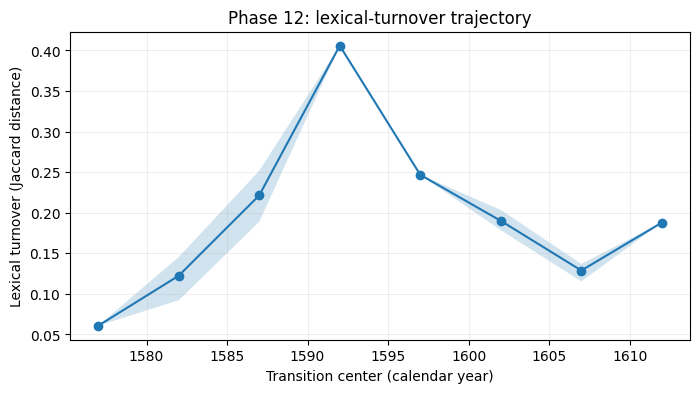

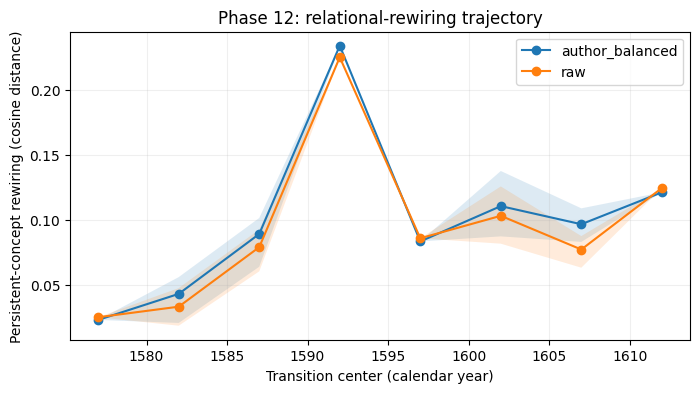

No vertical historiographic markers are plotted in Phase 12.


In [8]:
# Deterministic midpoint reference is QA/visualization only, never inferential evidence.
mid=((primary.composition_min+primary.composition_max)//2).to_numpy(int); ref_selected=[]
for start,end in MAIN_WINDOWS: ref_selected.append(tuple(sorted(ids[(mid>=start)&(mid<=end)].tolist())))
ref_rows=[]
for k in range(8):
    for mode in ('raw','author_balanced'):
        d=compare_states(build_state(ref_selected[k],mode),build_state(ref_selected[k+1],mode));
        d.update({'transition_index':k+1,'transition_center':((MAIN_WINDOWS[k][0]+MAIN_WINDOWS[k][1])/2+(MAIN_WINDOWS[k+1][0]+MAIN_WINDOWS[k+1][1])/2)/2,'mode':mode}); ref_rows.append(d)
midpoint_reference=pd.DataFrame(ref_rows)

import matplotlib.pyplot as plt
lex=trajectory_summary[trajectory_summary['mode'].eq('raw')].sort_values('transition_center')
plt.figure(figsize=(8,4)); plt.plot(lex.transition_center,lex.lexical_turnover_median,marker='o'); plt.fill_between(lex.transition_center,lex.lexical_turnover_q10,lex.lexical_turnover_q90,alpha=.2); plt.xlabel('Transition center (calendar year)'); plt.ylabel('Lexical turnover (Jaccard distance)'); plt.title('Phase 12: lexical-turnover trajectory'); plt.grid(alpha=.2); plt.show()
plt.figure(figsize=(8,4))
for mode,grp in trajectory_summary.groupby('mode'):
    grp=grp.sort_values('transition_center'); plt.plot(grp.transition_center,grp.rewiring_cosine_median,marker='o',label=mode); plt.fill_between(grp.transition_center,grp.rewiring_cosine_q10,grp.rewiring_cosine_q90,alpha=.15)
plt.xlabel('Transition center (calendar year)'); plt.ylabel('Persistent-concept rewiring (cosine distance)'); plt.title('Phase 12: relational-rewiring trajectory'); plt.legend(); plt.grid(alpha=.2); plt.show()
print('No vertical historiographic markers are plotted in Phase 12.')


In [9]:
OUT=Path('/content/gasr_phase12_outputs'); OUT.mkdir(exist_ok=True)
traj.to_csv(OUT/'phase12_mc_reconfiguration_trajectory.csv',index=False)
trajectory_summary.to_csv(OUT/'phase12_transition_summary.csv',index=False)
concordance.to_csv(OUT/'phase12_raw_vs_balanced_concordance.csv',index=False)
midpoint_reference.to_csv(OUT/'phase12_midpoint_reference_QA.csv',index=False)
metric_spec.to_csv(OUT/'phase12_frozen_metric_specification.csv',index=False)

assert len(primary)==97 and primary.author_dir.nunique()==6
assert len(MAIN_VOCAB)==668 and len(MAIN_WINDOWS)==9 and len(TRANSITIONS)==8
assert SELECTED_REPRESENTATION=='B_line_support1' and MIN_PAIR_SUPPORT==1
assert len(trajectory_summary)==16 and set(trajectory_summary['mode'])=={'raw','author_balanced'}
assert trajectory_summary.rewiring_cosine_valid_fraction.min()>0.95

print('\nPHASE 12 CHECKPOINT')
print('-------------------')
print('Primary chronology:',len(primary),'poems |',primary.author_dir.nunique(),'authors')
print('Main representation:',SELECTED_REPRESENTATION,'| poetic line | support >=1 | PPMI')
print('Main trajectory:',len(MAIN_WINDOWS),'windows ->',len(TRANSITIONS),'adjacent transitions')
print('Chronology realizations:',MC_DRAWS)
print('Draw-level transition-mode observations:',len(traj))
print('Primary lexical statistic: node-set Jaccard distance')
print('Primary relational statistic: cosine distance on PPMI edges among persistent concepts')
print('Secondary relational diagnostics: persistent-edge Jaccard + Jensen-Shannon divergence')
print('Raw + author-balanced modes: TRUE')
print('1580/1605 used in metric construction or tuning: FALSE')
print('Historiographic labels used in metric construction or tuning: FALSE')
print('Change point computed: FALSE')
print('Null/counterfactual significance test computed: FALSE')
print('Historical Renaissance/Baroque claim made: FALSE')
print('Next phase: null models and robustness before historiographic validation')
print('Outputs:',OUT)



PHASE 12 CHECKPOINT
-------------------
Primary chronology: 97 poems | 6 authors
Main representation: B_line_support1 | poetic line | support >=1 | PPMI
Main trajectory: 9 windows -> 8 adjacent transitions
Chronology realizations: 1000
Draw-level transition-mode observations: 16000
Primary lexical statistic: node-set Jaccard distance
Primary relational statistic: cosine distance on PPMI edges among persistent concepts
Secondary relational diagnostics: persistent-edge Jaccard + Jensen-Shannon divergence
Raw + author-balanced modes: TRUE
1580/1605 used in metric construction or tuning: FALSE
Historiographic labels used in metric construction or tuning: FALSE
Change point computed: FALSE
Null/counterfactual significance test computed: FALSE
Historical Renaissance/Baroque claim made: FALSE
Next phase: null models and robustness before historiographic validation
Outputs: /content/gasr_phase12_outputs
